In [5]:
import os
from pathlib import Path
os.environ["CUDA_VISIBLE_DEVICES"] = "3"


import torch
# torch.cuda.init()
print(os.environ.get("CUDA_VISIBLE_DEVICES"))
!source /home/jupyter/Mrigi/env.sh
hf_token = os.environ.get("HF_TOKEN")


torch.cuda.set_device(0)
import json

from langchain.embeddings import HuggingFaceEmbeddings
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline



3


In [6]:
from pydantic import BaseModel, Field
from typing import Optional, Union
from datetime import datetime
from tqdm import tqdm

In [7]:
!nvidia-smi

Thu Feb  5 17:12:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   48C    P0             71W /  230W |       0MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:

!kill -9 2582714


/bin/bash: line 0: kill: (2582714) - No such process


In [9]:
# ---------- Step 1: Load and Process the JSON Records ----------
# # Load JSON records from file
# with open('filtered_records_subset_100.json', 'r') as file:
#     filtered_records = json.load(file)

In [10]:
# Process each record: extract paragraphs with "Experimental" supersection,
# concatenate them, and append DOI info.
# documents = []
# metadata = []

In [11]:
# Process records into documents
# documents = []
# metadata = []

# for record in filtered_records:
#     doi = record.get("doi", "Unknown DOI")
    
#     # Add abstract as a separate document
#     abstract_text = record.get("abstract", "").strip()
#     if abstract_text:
#         combined_text = f"{abstract_text}\n\nThis information is from DOI: {doi}"
#         documents.append(combined_text)
#         metadata.append({"doi": doi, "source": "abstract"})
    
#     # Add each paragraph as a separate document
#     for para in record.get("paragraphs", []):
#         paragraph_text = para.get("text", "").strip()
#         if paragraph_text:
#             combined_text = f"{paragraph_text}\n\nThis information is from DOI: {doi}"
#             documents.append(combined_text)
#             metadata.append({"doi": doi, "source": "paragraph"})

# print(f"Total documents processed: {len(documents)}")

In [12]:
# for doc in documents:
#     print(doc)
#     print("-"*40)  # Optional: adds a visual separator between different papers


In [13]:
# ---------- Step 2: Prepare Embeddings for the Existing FAISS Index ----------
# Use the same model configuration that was used when the index was created.
# embeddings = HuggingFaceEmbeddings(model_name="allenai/scibert_scivocab_uncased")
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

/tmp/ipykernel_2851800/2006348050.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


In [14]:
# ---------- Step 2: Load the Existing Vector Database from Disk ----------
INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"
if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

# Use allow_dangerous_deserialization=True to load indices saved with pickle-based metadata.
vector_db = FAISS.load_local(
    INDEX_DIRECTORY,
    embeddings,
    index_name=INDEX_NAME,
    allow_dangerous_deserialization=True
)
print(f"Loaded vector database from {INDEX_DIRECTORY} with {vector_db.index.ntotal} vectors")

Loaded vector database from faiss_index with 1474439 vectors


In [15]:
# # Print DOIs for up to the first 50 processed documents
# if not metadata:
#     print("No metadata available. Did you load the records?")
# else:
#     for entry in metadata[:50]:
#         print(entry.get("doi", "Unknown DOI"))

In [16]:
# ---------- Step 3: Use the Vector DB in a RAG Pipeline ----------
# Define your query.
# query = "How is hierarchical ZSM-5 synthesized?"
# query = "What is the best way to synthesize ZSM-5 that is hierarchical?"
# query = "How is Silicalite-1 synthesized?"
query = "How can you study the effect of nature of silica source on the purity of template-free ZSM-5?"


In [17]:
# Retrieve top k relevant documents (papers) from the vector database.
retrieved_docs = vector_db.similarity_search(query, k=4)
context_text = "\n\n".join([doc.page_content for doc in retrieved_docs])

In [18]:
# print(embeddings.embed_query("Silicalite-1 synthesis"))
# print(embeddings.embed_documents(["test text 1", "test text 2"]))


In [19]:
context_text

'For ZSM-5, the best results were obtained with an undiluted synthesis solution, in contrast to silicalite. At 180 degC and 4 h of reaction time, the synthesis procedure for ZSM-5 proved to be highly reproducible (entries 13-16) in terms of layer thickness.\n\nThis information is from DOI: 10.1016/j.snb.2016.05.133\n\nFor ZSM-5, the best results were obtained with an undiluted synthesis solution, in contrast to silicalite. At 180 degC and 4 h of reaction time, the synthesis procedure for ZSM-5 proved to be highly reproducible (entries 13-16) in terms of layer thickness.\n\nThis information is from DOI: 10.1016/j.snb.2016.05.133\n\nFinally, the Si/Al ratios of the optimized ZSM-5 samples vary between 59-63. Considering that 15 mol % of SiO2 was in the silicalite-1 seeds and thus 85 mol % of SiO2 in the ZSM-5 phase, the actual Si/Al ratio in the ZSM-5 phase varied between 69-74. This shows that Al is fully incorporated into the ZSM-5 phase.\n\nThis information is from DOI: 10.1002/cctc.2

In [20]:
# RAG prompt template
RAG_PROMPT = """
Answer the question based only on the following context:
{context}
Question: {question}
Provide a detailed answer.
Provide which DOI the answer is retrieved from.
"""



In [21]:
rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)
prompt = rag_prompt.format(context=context_text, question=query)

In [22]:
# ---------- Step 4: Generate an Answer Using an Open-Source LLM ----------
# Setup the open source LLM using Mistral (ensure you have the model or access to it)
model_name = "mistralai/Mistral-7B-Instruct-v0.1"

In [23]:
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=False, use_auth_token=hf_token)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [24]:
from transformers.models.auto.configuration_auto import CONFIG_MAPPING
print("Supported model types:", list(CONFIG_MAPPING.keys()))

Supported model types: ['albert', 'align', 'altclip', 'audio-spectrogram-transformer', 'autoformer', 'bark', 'bart', 'beit', 'bert', 'bert-generation', 'big_bird', 'bigbird_pegasus', 'biogpt', 'bit', 'blenderbot', 'blenderbot-small', 'blip', 'blip-2', 'bloom', 'bridgetower', 'bros', 'camembert', 'canine', 'chinese_clip', 'clap', 'clip', 'clipseg', 'code_llama', 'codegen', 'conditional_detr', 'convbert', 'convnext', 'convnextv2', 'cpmant', 'ctrl', 'cvt', 'data2vec-audio', 'data2vec-text', 'data2vec-vision', 'deberta', 'deberta-v2', 'decision_transformer', 'deformable_detr', 'deit', 'deta', 'detr', 'dinat', 'dinov2', 'distilbert', 'donut-swin', 'dpr', 'dpt', 'efficientformer', 'efficientnet', 'electra', 'encodec', 'encoder-decoder', 'ernie', 'ernie_m', 'esm', 'falcon', 'flaubert', 'flava', 'fnet', 'focalnet', 'fsmt', 'funnel', 'git', 'glpn', 'gpt-sw3', 'gpt2', 'gpt_bigcode', 'gpt_neo', 'gpt_neox', 'gpt_neox_japanese', 'gptj', 'gptsan-japanese', 'graphormer', 'groupvit', 'hubert', 'ibert'

In [25]:
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", trust_remote_code=True, use_auth_token=hf_token, torch_dtype=torch.float16)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [26]:
hf_pipeline = pipeline("text-generation", model=model, tokenizer=tokenizer, max_length=10000)

In [27]:
# Wrap the Hugging Face pipeline with LangChain's HuggingFacePipeline interface.
rag_llm = HuggingFacePipeline(pipeline=hf_pipeline)



/tmp/ipykernel_2851800/4067646612.py:2: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  rag_llm = HuggingFacePipeline(pipeline=hf_pipeline)


In [28]:
# Generate the answer based on the prompt that includes retrieved context.
# response_text = rag_llm(prompt)
# print("Response:")
# print(response_text)

In [29]:
import random

def get_unique_dois_with_titles(vector_db, limit=100, random_sample=True):
    """Extract unique DOIs and their associated titles from the vector store
    
    Args:
        vector_db: FAISS vector database
        limit: Number of DOIs to return (default 100)
        random_sample: If True, randomly sample from all DOIs; if False, take first N
    """
    seen_dois = set()
    doi_titles = []
    
    # Get all documents
    all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
    
    for doc in all_docs:
        # Extract DOI from the document content
        content = doc.page_content
        metadata = doc.metadata
        
        # Find DOI in the content (it's typically at the end of each document)
        if "This information is from DOI:" in content:
            doi = content.split("This information is from DOI:")[-1].strip()
            
            if doi not in seen_dois:
                seen_dois.add(doi)
                # Look for title in metadata or content
                title = metadata.get('title', 'Title not found')
                doi_titles.append({'doi': doi, 'title': title})
    
    # Apply random sampling if requested
    if random_sample and len(doi_titles) > limit:
        random.seed(42)  # Set seed for reproducibility
        doi_titles = random.sample(doi_titles, limit)
    else:
        doi_titles = doi_titles[:limit]
    
    return doi_titles

# Get 100 randomly sampled unique DOIs with titles
unique_entries = get_unique_dois_with_titles(vector_db, limit=100, random_sample=True)
print(f"\nRandomly sampled {len(unique_entries)} unique DOIs from the database")
print(f"First 5 samples:")
for entry in unique_entries[:5]:
    print(f"\nDOI: {entry['doi']}")
    print(f"Title: {entry['title']}")
print("\n" + "="*80)


Randomly sampled 100 unique DOIs from the database
First 5 samples:

DOI: 10.1016/j.jmr.2015.12.009
Title: Title not found

DOI: 10.1038/s41467-017-01765-0
Title: Title not found

DOI: 10.1039/d1ta10008d
Title: Title not found

DOI: 10.1002/anie.200219624
Title: Title not found

DOI: 10.1021/jp205312k
Title: Title not found



In [30]:
# Load the filtered records that contain title information
with open('filtered_records_on_zeolite.json', 'r') as f:
    filtered_records = json.load(f)

# Get DOIs from our vector database
vector_dois = {entry['doi'] for entry in unique_entries}

# Create enriched records matching vector DOIs (DEDUPLICATED by DOI)
seen_dois = set()
enriched_records = []
for record in filtered_records:
    doi = record.get('doi')
    # Only add if: 1) DOI is in vector_dois AND 2) we haven't seen this DOI yet
    if doi in vector_dois and doi not in seen_dois:
        seen_dois.add(doi)
        enriched_record = {
            'doi': doi,
            'title': record.get('title', 'No title'),
        }
        enriched_records.append(enriched_record)

# Save the matched records
output_path = Path('zeolite_papers_with_titles.json')
with output_path.open('w') as f:
    json.dump(enriched_records, f, indent=2)

print(f"Saved {len(enriched_records)} matched UNIQUE records with titles to {output_path}")
print(f"Started with {len(unique_entries)} sampled DOIs, matched {len(enriched_records)} unique DOIs")
print("\nFirst few entries:")
for record in enriched_records[:3]:
    print(f"\nTitle: {record['title']}")
    print(f"DOI: {record['doi']}")

Saved 100 matched UNIQUE records with titles to zeolite_papers_with_titles.json
Started with 100 sampled DOIs, matched 100 unique DOIs

First few entries:

Title: Investigating the effects of alkali metal Na addition on catalytic activity of HZSM-5 for methyl mercaptan elimination
DOI: 10.1016/j.apsusc.2017.05.134

Title: A “Camel through the Eye of a Needle”: Direct Introduction of the TPP+ Ion inside Y‐Zeolites by Formal Ion Exchange in Aqueous Medium
DOI: 10.1002/anie.200219624

Title: Production of low-oxygen bio-oil via ex situ catalytic fast pyrolysis and hydrotreating
DOI: 10.1016/j.fuel.2017.06.098


## Evaluating Retrieval Accuracy

We'll use the titles as queries and check if the retrieved documents' DOIs match the ground truth DOIs. We'll calculate:
1. Top-1 accuracy: Does the first retrieved document match?
2. Top-5 accuracy: Do any of the first 5 retrieved documents match?
3. Top-10 accuracy: Do any of the first 10 retrieved documents match?

In [31]:
def evaluate_retrieval_accuracy(records, vector_db, k=10):
    """Evaluate retrieval accuracy using titles as queries.
    Args:
        records: List of dicts containing 'title' and 'doi' pairs
        vector_db: FAISS vector store
        k: Number of documents to retrieve (default=10 for all metrics)
    Returns:
        Dictionary with accuracy metrics
    """
    total = 0  # Will only count records with valid titles
    correct_at_1 = 0
    correct_at_5 = 0
    correct_at_10 = 0
    
    print(f"Processing {len(records)} records...")
    for record in tqdm(records):
        # Skip records without title or doi
        query = record.get('title')
        true_doi = record.get('doi')
        if not query or not true_doi:
            continue
        total += 1
        
        # Get top k retrieved documents
        retrieved_docs = vector_db.similarity_search(query, k=k)
        
        # Extract DOIs from retrieved documents
        retrieved_dois = []
        for doc in retrieved_docs:
            content = doc.page_content
            if "This information is from DOI:" in content:
                doi = content.split("This information is from DOI:")[-1].strip()
                retrieved_dois.append(doi)
        
        # Check accuracy at different k values
        if retrieved_dois and retrieved_dois[0] == true_doi:
            correct_at_1 += 1
        if any(doi == true_doi for doi in retrieved_dois[:5]):
            correct_at_5 += 1
        if any(doi == true_doi for doi in retrieved_dois[:10]):
            correct_at_10 += 1
    
    # Calculate accuracy scores
    accuracy = {
        'top_1': correct_at_1 / total * 100,
        'top_5': correct_at_5 / total * 100,
        'top_10': correct_at_10 / total * 100
    }
    
    return accuracy

In [32]:
# Run evaluation
accuracy_results = evaluate_retrieval_accuracy(enriched_records, vector_db)

print("="*80)
print("TITLE-BASED RETRIEVAL ACCURACY RESULTS")
print("="*80)
print(f"Test Dataset Size: {len(enriched_records)} DOI-title pairs (randomly sampled)")
print(f"\nAccuracy Metrics:")
print(f"  Top-1 Accuracy:  {accuracy_results['top_1']:.2f}% ({int(accuracy_results['top_1']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-5 Accuracy:  {accuracy_results['top_5']:.2f}% ({int(accuracy_results['top_5']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-10 Accuracy: {accuracy_results['top_10']:.2f}% ({int(accuracy_results['top_10']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print("="*80)

Processing 100 records...


100%|██████████| 100/100 [00:17<00:00,  5.84it/s]

TITLE-BASED RETRIEVAL ACCURACY RESULTS
Test Dataset Size: 100 DOI-title pairs (randomly sampled)

Accuracy Metrics:
  Top-1 Accuracy:  39.58% (39/100 correct)
  Top-5 Accuracy:  69.79% (69/100 correct)
  Top-10 Accuracy: 82.29% (82/100 correct)


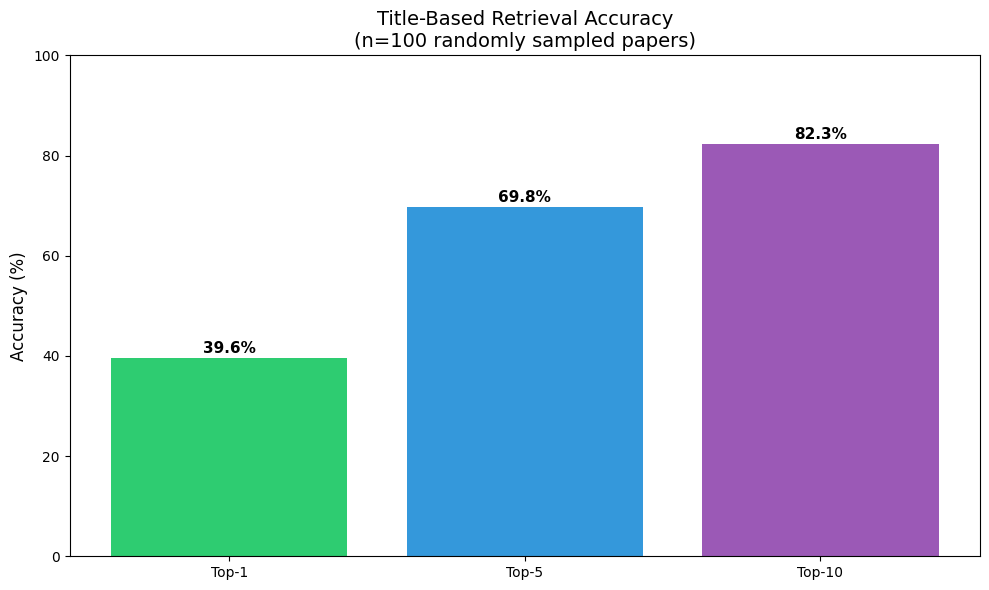

In [33]:
import matplotlib.pyplot as plt

# Create bar plot
plt.figure(figsize=(10, 6))
metrics = ['Top-1', 'Top-5', 'Top-10']
values = [accuracy_results['top_1'], accuracy_results['top_5'], accuracy_results['top_10']]

plt.bar(metrics, values, color=['#2ecc71', '#3498db', '#9b59b6'])
plt.title(f'Title-Based Retrieval Accuracy\n(n={len(enriched_records)} randomly sampled papers)', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)

# Add value labels on top of each bar
for i, v in enumerate(values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## ZeoSyn-based benchmarking using framework queries

We will:
- Load queries from `zeolite_synthesis_questions.txt`
- For each query, extract the framework code(s) (e.g., MFI, BEA, FAU; ignore decorations like `*` or `-`)
- Retrieve top-K documents from the FAISS vector DB and extract DOIs
- Load the ZeoSyn database (we only need `doi`, `Code1`, `Code2`, `Code3`)
- Count a hit@K if ANY of the top-K DOIs appears under ANY of the parsed framework codes in ZeoSyn

Please set `ZEOSYN_PATH` to the Excel/CSV file with those columns before running the evaluation cells below.

In [34]:
# --- Helpers: DOI normalization, framework parsing, ZeoSyn loading, topK retrieval ---
import re
import pandas as pd
from collections import defaultdict
from typing import List, Dict, Set


def normalize_doi(doi: str) -> str:
    if doi is None:
        return ""
    d = str(doi).strip().lower()
    # remove common prefixes
    d = re.sub(r"^(https?://(dx\.)?doi\.org/)", "", d)
    d = re.sub(r"^doi:\s*", "", d)
    return d.strip()


def parse_frameworks_from_query(query: str) -> List[str]:
    """Extract framework code(s) from a question string.
    Examples:
      "Give me synthesis conditions for a *BEA/BEC recipe." -> ["BEA","BEC"]
      "Give me synthesis conditions for a EUO/*MRE recipe." -> ["EUO","MRE"]
      "Give me synthesis conditions for a ASU-12 recipe." -> ["ASU-12"]
      "Give me synthesis conditions for a -SVR recipe." -> ["SVR"]
    """
    # Try to capture the segment between 'for a ' and ' recipe'
    m = re.search(r"for a\s+(.*?)\s+recipe\.?", query, flags=re.IGNORECASE)
    segment = m.group(1) if m else query
    # Split on '/' first to handle combos
    parts = re.split(r"/", segment)
    frameworks = []
    for p in parts:
        # Strip leading decorations like '*' or '-' and trailing punctuation
        token = p.strip().strip('.').strip()
        token = re.sub(r"^[\*-]+", "", token)
        # Keep internal hyphens/digits (e.g., ASU-12)
        # Reduce multiple spaces
        token = re.sub(r"\s+", " ", token)
        token = token.upper()
        token = token.strip()
        if token:
            frameworks.append(token)
    # Some segments include extra words; try to filter by typical code patterns
    cleaned = []
    for t in frameworks:
        # Accept tokens of pattern AAA, AAA-12, or alphanum combos up to ~10 chars
        if re.match(r"^[A-Z]{2,}(?:-[0-9A-Z]+)?$", t):
            cleaned.append(t)
        else:
            # Try last all-caps chunk in token
            caps = re.findall(r"[A-Z]{2,}(?:-[0-9A-Z]+)?", t)
            cleaned.extend(caps)
    # Deduplicate preserving order
    seen = set()
    out = []
    for c in cleaned:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out


def load_zeosyn_framework_to_doi_map(path: str) -> Dict[str, Set[str]]:
    """Load ZeoSyn Excel/CSV and return mapping: FRAMEWORK_CODE -> set(normalized_doi)."""
    if path.lower().endswith(".csv"):
        df = pd.read_csv(path)
    else:
        # default to excel
        df = pd.read_excel(path)
    # Normalize columns
    cols = {c.lower(): c for c in df.columns}
    # Try to find doi and code columns case-insensitively
    doi_col = cols.get("doi")
    # Common variants
    if doi_col is None:
        for cand in df.columns:
            if cand.lower().startswith("doi"):
                doi_col = cand
                break
    code_cols = []
    for key in ["code1", "code2", "code3"]:
        if key in cols:
            code_cols.append(cols[key])
    # Fallback: any column named like 'code' variants
    if not code_cols:
        for cand in df.columns:
            if re.match(r"code[123]$", cand.lower()):
                code_cols.append(cand)
    if doi_col is None or not code_cols:
        raise ValueError("Could not locate 'doi' and 'Code1/Code2/Code3' columns in ZeoSyn file.")

    fmap: Dict[str, Set[str]] = defaultdict(set)
    for _, row in df.iterrows():
        doi = normalize_doi(row.get(doi_col, ""))
        if not doi:
            continue
        codes = []
        for c in code_cols:
            val = row.get(c)
            if pd.isna(val):
                continue
            code = str(val).strip().upper()
            if code:
                codes.append(code)
        for code in codes:
            fmap[code].add(doi)
    return fmap


def get_topk_unique_dois(vector_db, query: str, k: int) -> List[str]:
    docs = vector_db.similarity_search(query, k=k)
    dois = []
    for doc in docs:
        content = doc.page_content or ""
        # Prefer the explicit tag; else try to regex a DOI-looking string
        if "This information is from DOI:" in content:
            doi = content.split("This information is from DOI:")[-1].strip()
            doi = normalize_doi(doi)
            if doi:
                dois.append(doi)
        else:
            m = re.search(r"\b10\.\d{4,9}/[-._;()/:A-Z0-9]+", content, flags=re.IGNORECASE)
            if m:
                dois.append(normalize_doi(m.group(0)))
    # Deduplicate preserving order
    seen = set()
    ordered = []
    for d in dois:
        if d and d not in seen:
            seen.add(d)
            ordered.append(d)
    return ordered[:k]


def evaluate_questions_against_zeosyn(questions_path: str, vector_db, zeosyn_map: Dict[str, Set[str]], ks=(1,3,5)):
    # Load questions
    with open(questions_path, 'r') as f:
        questions = [q.strip() for q in f if q.strip()]

    totals = {k: 0 for k in ks}
    hits = {k: 0 for k in ks}
    per_question = []

    for q in tqdm(questions):
        frameworks = parse_frameworks_from_query(q)
        # Combine all ZeoSyn DOIs for these frameworks
        zeo_dois: Set[str] = set()
        for fw in frameworks:
            # Exact match
            if fw in zeosyn_map:
                zeo_dois |= zeosyn_map[fw]
            # Some frameworks may appear with leading '*' or '-' stripped already; try another heuristic:
            alt_fw = fw.lstrip("*- ")
            if alt_fw in zeosyn_map:
                zeo_dois |= zeosyn_map[alt_fw]
        result = {"question": q, "frameworks": frameworks, "zeosyn_dois_count": len(zeo_dois)}

        # Skip if we cannot map any DOI for the frameworks; we still count towards totals per your rule? We'll include and likely be miss unless retrieved DOI happens to be present.
        for k in ks:
            totals[k] += 1
            top_dois = get_topk_unique_dois(vector_db, q, k)
            matched = [d for d in top_dois if d in zeo_dois]
            hit = len(matched) > 0
            if hit:
                hits[k] += 1
            result[f"top{k}_dois"] = top_dois
            result[f"top{k}_hit"] = hit
            result[f"top{k}_matched"] = matched
        per_question.append(result)

    accuracies = {f"top_{k}": (hits[k] / totals[k] * 100 if totals[k] else 0.0) for k in ks}
    summary = {"totals": totals, "hits": hits, "accuracies": accuracies}
    return summary, per_question

In [35]:
# # --- Configure paths and run ZeoSyn evaluation ---
# # Set to your actual ZeoSyn file path (Excel or CSV with columns: doi, Code1, Code2, Code3)
# ZEOSYN_PATH = "ZEOSYN.xlsx" 
# QUESTIONS_PATH = "zeolite_synthesis_questions.txt"  # provided

# # Load ZeoSyn mapping
# try:
#     zeo_map = load_zeosyn_framework_to_doi_map(ZEOSYN_PATH)
#     print(f"Loaded ZeoSyn map with {len(zeo_map)} framework entries")
# except Exception as e:
#     print("Failed to load ZeoSyn file:", e)
#     zeo_map = {}

# # Evaluate
# summary, per_q = evaluate_questions_against_zeosyn(
#     QUESTIONS_PATH,
#     vector_db,
#     zeo_map,
#     ks=(1,3,5)
# )

# print("ZeoSyn Retrieval Accuracy (Hit@K by framework):")
# for k, v in summary["accuracies"].items():
#     print(f"  {k}: {v:.2f}%  (hits={summary['hits'][int(k.split('_')[1])]}/total={summary['totals'][int(k.split('_')[1])]})")

# # Save detailed results
# details_path_json = "zeosyn_benchmark_details.json"
# with open(details_path_json, "w") as f:
#     json.dump({"summary": summary, "results": per_q}, f, indent=2)
# print(f"Saved detailed results to {details_path_json}")

In [36]:
# # --- Optional: visualize ZeoSyn Hit@K ---
# import matplotlib.pyplot as plt

# labels = ["Top-1", "Top-3", "Top-5"]
# vals = [summary["accuracies"]["top_1"], summary["accuracies"]["top_3"], summary["accuracies"]["top_5"]]
# plt.figure(figsize=(8,5))
# plt.bar(labels, vals, color=["#2ecc71", "#3498db", "#9b59b6"]) 
# plt.ylim(0, 100)
# for i, v in enumerate(vals):
#     plt.text(i, v + 1, f"{v:.1f}%", ha="center")
# plt.title("ZeoSyn Hit@K accuracy (framework-aware)")
# plt.ylabel("Accuracy (%)")
# plt.show()

## Hybrid Retrieval: MMR + BM25 Evaluation

Now we'll implement hybrid retrieval combining:
- **BM25**: Keyword-based retrieval (top-5)
- **MMR**: Semantic similarity with diversity (top-5)
- **Combined**: Deduplicated results from both methods

We'll evaluate the same title-based retrieval accuracy with this hybrid approach and compare it to the pure FAISS results above.

In [37]:
# Import BM25 retriever
from langchain.retrievers import BM25Retriever

# Initialize BM25 retriever for hybrid search
print("Initializing BM25 retriever...")
all_docs = list(vector_db.docstore._dict.values())
bm25_retriever = BM25Retriever.from_documents(all_docs)
bm25_retriever.k = 10  # Set to retrieve top 10 documents

print(f"BM25 retriever initialized with {len(all_docs)} documents")
print("BM25 retriever ready!")

Initializing BM25 retriever...
BM25 retriever initialized with 1474439 documents
BM25 retriever ready!
BM25 retriever initialized with 1474439 documents
BM25 retriever ready!


In [38]:
def hybrid_search(query: str, vector_db, bm25_retriever, k_total=10, k_bm25=10, k_mmr=10, 
                  mmr_fetch_k=40, mmr_lambda=0.6):
    """
    Performs hybrid retrieval combining BM25 and MMR.
    
    Args:
        query: Search query string
        vector_db: FAISS vector database
        bm25_retriever: BM25 retriever instance
        k_total: Total number of unique documents to return
        k_bm25: Number of documents to retrieve from BM25
        k_mmr: Number of documents to retrieve from MMR
        mmr_fetch_k: Number of candidates for MMR to consider
        mmr_lambda: MMR lambda parameter (0=max diversity, 1=max relevance)
    
    Returns:
        List of unique documents combined from both retrievers
    """
    # Get BM25 results (keyword-based)
    bm25_retriever.k = k_bm25
    bm25_docs = bm25_retriever.get_relevant_documents(query)
    
    # Get MMR results (semantic + diversity)
    mmr_docs = vector_db.max_marginal_relevance_search(
        query,
        k=k_mmr,
        fetch_k=mmr_fetch_k,
        lambda_mult=mmr_lambda
    )
    
    # Combine and deduplicate based on page_content
    seen_contents = set()
    combined_docs = []
    
    # Add BM25 results first (prioritize keyword matches)
    for doc in bm25_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_contents:
            seen_contents.add(content_hash)
            combined_docs.append(doc)
    
    # Add MMR results
    for doc in mmr_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_contents:
            seen_contents.add(content_hash)
            combined_docs.append(doc)
    
    return combined_docs[:k_total]

print("Hybrid search function defined!")

Hybrid search function defined!


In [39]:
def evaluate_hybrid_retrieval_accuracy(records, vector_db, bm25_retriever, k=10):
    """Evaluate hybrid retrieval accuracy using titles as queries.
    
    Args:
        records: List of dicts containing 'title' and 'doi' pairs
        vector_db: FAISS vector store
        bm25_retriever: BM25 retriever instance
        k: Number of documents to retrieve (default=10 for all metrics)
    
    Returns:
        Dictionary with accuracy metrics
    """
    total = 0
    correct_at_1 = 0
    correct_at_5 = 0
    correct_at_10 = 0
    
    print(f"Processing {len(records)} records with hybrid retrieval...")
    for record in tqdm(records):
        # Skip records without title or doi
        query = record.get('title')
        true_doi = record.get('doi')
        if not query or not true_doi:
            continue
        total += 1
        
        # Get top k retrieved documents using hybrid search
        retrieved_docs = hybrid_search(
            query, 
            vector_db, 
            bm25_retriever,
            k_total=k,
            k_bm25=10,
            k_mmr=10,
            mmr_fetch_k=40,
            mmr_lambda=0.6
        )
        
        # Extract DOIs from retrieved documents
        retrieved_dois = []
        for doc in retrieved_docs:
            content = doc.page_content
            if "This information is from DOI:" in content:
                doi = content.split("This information is from DOI:")[-1].strip()
                retrieved_dois.append(doi)
        
        # Check accuracy at different k values
        if retrieved_dois and retrieved_dois[0] == true_doi:
            correct_at_1 += 1
        if any(doi == true_doi for doi in retrieved_dois[:5]):
            correct_at_5 += 1
        if any(doi == true_doi for doi in retrieved_dois[:10]):
            correct_at_10 += 1
    
    # Calculate accuracy scores
    accuracy = {
        'top_1': correct_at_1 / total * 100,
        'top_5': correct_at_5 / total * 100,
        'top_10': correct_at_10 / total * 100
    }
    
    return accuracy

print("Hybrid evaluation function defined!")

Hybrid evaluation function defined!


In [40]:
# Run hybrid evaluation on the same test set
hybrid_accuracy_results = evaluate_hybrid_retrieval_accuracy(enriched_records, vector_db, bm25_retriever)

print("\n" + "="*80)
print("HYBRID RETRIEVAL ACCURACY RESULTS (MMR + BM25)")
print("="*80)
print(f"Test Dataset Size: {len(enriched_records)} DOI-title pairs (same as above)")
print(f"\nAccuracy Metrics:")
print(f"  Top-1 Accuracy:  {hybrid_accuracy_results['top_1']:.2f}% ({int(hybrid_accuracy_results['top_1']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-5 Accuracy:  {hybrid_accuracy_results['top_5']:.2f}% ({int(hybrid_accuracy_results['top_5']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-10 Accuracy: {hybrid_accuracy_results['top_10']:.2f}% ({int(hybrid_accuracy_results['top_10']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print("="*80)

Processing 100 records with hybrid retrieval...


  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_2851800/21321534.py:21: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  bm25_docs = bm25_retriever.get_relevant_documents(query)
/tmp/ipykernel_2851800/21321534.py:21: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  bm25_docs = bm25_retriever.get_relevant_documents(query)
100%|██████████| 100/100 [09:52<00:00,  5.93s/it]


HYBRID RETRIEVAL ACCURACY RESULTS (MMR + BM25)
Test Dataset Size: 100 DOI-title pairs (same as above)

Accuracy Metrics:
  Top-1 Accuracy:  36.46% (36/100 correct)
  Top-5 Accuracy:  54.17% (54/100 correct)
  Top-10 Accuracy: 66.67% (66/100 correct)


## Individual Retriever Evaluation: BM25 Only and MMR Only

Now we'll evaluate each retrieval method individually:
- **BM25 Only**: Pure keyword-based retrieval
- **MMR Only**: Pure semantic search with diversity

In [41]:
def evaluate_bm25_only_accuracy(records, bm25_retriever, k=10):
    """Evaluate BM25-only retrieval accuracy using titles as queries.
    
    Args:
        records: List of dicts containing 'title' and 'doi' pairs
        bm25_retriever: BM25 retriever instance
        k: Number of documents to retrieve (default=10 for all metrics)
    
    Returns:
        Dictionary with accuracy metrics
    """
    total = 0
    correct_at_1 = 0
    correct_at_5 = 0
    correct_at_10 = 0
    
    print(f"Processing {len(records)} records with BM25-only retrieval...")
    for record in tqdm(records):
        # Skip records without title or doi
        query = record.get('title')
        true_doi = record.get('doi')
        if not query or not true_doi:
            continue
        total += 1
        
        # Get top k retrieved documents using BM25 only
        bm25_retriever.k = k
        retrieved_docs = bm25_retriever.get_relevant_documents(query)
        
        # Extract DOIs from retrieved documents
        retrieved_dois = []
        for doc in retrieved_docs:
            content = doc.page_content
            if "This information is from DOI:" in content:
                doi = content.split("This information is from DOI:")[-1].strip()
                retrieved_dois.append(doi)
        
        # Check accuracy at different k values
        if retrieved_dois and retrieved_dois[0] == true_doi:
            correct_at_1 += 1
        if any(doi == true_doi for doi in retrieved_dois[:5]):
            correct_at_5 += 1
        if any(doi == true_doi for doi in retrieved_dois[:10]):
            correct_at_10 += 1
    
    # Calculate accuracy scores
    accuracy = {
        'top_1': correct_at_1 / total * 100,
        'top_5': correct_at_5 / total * 100,
        'top_10': correct_at_10 / total * 100
    }
    
    return accuracy

print("BM25-only evaluation function defined!")

BM25-only evaluation function defined!


In [42]:
def evaluate_mmr_only_accuracy(records, vector_db, k=10):
    """Evaluate MMR-only retrieval accuracy using titles as queries.
    
    Args:
        records: List of dicts containing 'title' and 'doi' pairs
        vector_db: FAISS vector store
        k: Number of documents to retrieve (default=10 for all metrics)
    
    Returns:
        Dictionary with accuracy metrics
    """
    total = 0
    correct_at_1 = 0
    correct_at_5 = 0
    correct_at_10 = 0
    
    print(f"Processing {len(records)} records with MMR-only retrieval...")
    for record in tqdm(records):
        # Skip records without title or doi
        query = record.get('title')
        true_doi = record.get('doi')
        if not query or not true_doi:
            continue
        total += 1
        
        # Get top k retrieved documents using MMR only
        retrieved_docs = vector_db.max_marginal_relevance_search(
            query,
            k=k,
            fetch_k=40,  # Candidate pool
            lambda_mult=0.6  # Balance between relevance and diversity
        )
        
        # Extract DOIs from retrieved documents
        retrieved_dois = []
        for doc in retrieved_docs:
            content = doc.page_content
            if "This information is from DOI:" in content:
                doi = content.split("This information is from DOI:")[-1].strip()
                retrieved_dois.append(doi)
        
        # Check accuracy at different k values
        if retrieved_dois and retrieved_dois[0] == true_doi:
            correct_at_1 += 1
        if any(doi == true_doi for doi in retrieved_dois[:5]):
            correct_at_5 += 1
        if any(doi == true_doi for doi in retrieved_dois[:10]):
            correct_at_10 += 1
    
    # Calculate accuracy scores
    accuracy = {
        'top_1': correct_at_1 / total * 100,
        'top_5': correct_at_5 / total * 100,
        'top_10': correct_at_10 / total * 100
    }
    
    return accuracy

print("MMR-only evaluation function defined!")

MMR-only evaluation function defined!


In [43]:
# Run BM25-only evaluation
bm25_accuracy_results = evaluate_bm25_only_accuracy(enriched_records, bm25_retriever)

print("\n" + "="*80)
print("BM25-ONLY RETRIEVAL ACCURACY RESULTS")
print("="*80)
print(f"Test Dataset Size: {len(enriched_records)} DOI-title pairs")
print(f"\nAccuracy Metrics:")
print(f"  Top-1 Accuracy:  {bm25_accuracy_results['top_1']:.2f}% ({int(bm25_accuracy_results['top_1']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-5 Accuracy:  {bm25_accuracy_results['top_5']:.2f}% ({int(bm25_accuracy_results['top_5']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-10 Accuracy: {bm25_accuracy_results['top_10']:.2f}% ({int(bm25_accuracy_results['top_10']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print("="*80)

Processing 100 records with BM25-only retrieval...


100%|██████████| 100/100 [09:42<00:00,  5.83s/it]


BM25-ONLY RETRIEVAL ACCURACY RESULTS
Test Dataset Size: 100 DOI-title pairs

Accuracy Metrics:
  Top-1 Accuracy:  36.46% (36/100 correct)
  Top-5 Accuracy:  53.12% (53/100 correct)
  Top-10 Accuracy: 57.29% (57/100 correct)


In [44]:
# Run MMR-only evaluation
mmr_accuracy_results = evaluate_mmr_only_accuracy(enriched_records, vector_db)

print("\n" + "="*80)
print("MMR-ONLY RETRIEVAL ACCURACY RESULTS")
print("="*80)
print(f"Test Dataset Size: {len(enriched_records)} DOI-title pairs")
print(f"\nAccuracy Metrics:")
print(f"  Top-1 Accuracy:  {mmr_accuracy_results['top_1']:.2f}% ({int(mmr_accuracy_results['top_1']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-5 Accuracy:  {mmr_accuracy_results['top_5']:.2f}% ({int(mmr_accuracy_results['top_5']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-10 Accuracy: {mmr_accuracy_results['top_10']:.2f}% ({int(mmr_accuracy_results['top_10']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print("="*80)

Processing 100 records with MMR-only retrieval...


100%|██████████| 100/100 [00:13<00:00,  7.16it/s]


MMR-ONLY RETRIEVAL ACCURACY RESULTS
Test Dataset Size: 100 DOI-title pairs

Accuracy Metrics:
  Top-1 Accuracy:  39.58% (39/100 correct)
  Top-5 Accuracy:  69.79% (69/100 correct)
  Top-10 Accuracy: 82.29% (82/100 correct)


## LLM-Optimized Query Retrieval Evaluation

Now we'll evaluate retrieval using LLM-optimized queries:
- **LLM Query Optimizer**: Uses Mistral-7B to convert paper titles into keyword-rich search queries
- **Retrieval Method**: FAISS semantic similarity search with optimized queries
- **Goal**: Test if optimized queries improve retrieval accuracy

In [45]:
# Load Mistral-7B model for query optimization
print("Loading Mistral-7B model for query optimization...")
print("This may take a few minutes...")

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=False, use_auth_token=hf_token)
print(f"Tokenizer loaded: {model_name}")

# Load model on GPU
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    device_map="auto", 
    trust_remote_code=True, 
    use_auth_token=hf_token, 
    torch_dtype=torch.float16
)
print(f"Model loaded on device: {model.device}")

# Create text generation pipeline
llm_pipeline = pipeline(
    "text-generation", 
    model=model, 
    tokenizer=tokenizer, 
    max_new_tokens=100,  # Limit tokens for concise queries
    do_sample=False,  # Deterministic generation
    temperature=0.1  # Low temperature for consistency
)
print("LLM pipeline ready for query optimization!")
print("="*80)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading Mistral-7B model for query optimization...
This may take a few minutes...
Tokenizer loaded: mistralai/Mistral-7B-Instruct-v0.1


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded on device: cuda:0
LLM pipeline ready for query optimization!


In [46]:
def optimize_query_with_llm(title: str, llm_pipeline) -> str:
    """
    Use LLM to convert a paper title into an optimized search query.
    
    Args:
        title: Original paper title
        llm_pipeline: Hugging Face text generation pipeline
    
    Returns:
        Optimized search query string
    """
    prompt = f"""You are helping optimize academic paper titles for literature search.
Given a research paper title, rewrite it as a concise keyword-based search query.
Keep only the most informative scientific terms (materials, methods, reactions, target compounds, properties) and remove any generic ones.
Remove filler words, metaphors and stylistic phrasing.
Preserve chemical formulas, abbreviations, and domain-specific terminology.
Output a single line of lowercase keywords in a natural but compact order.
Do not explain or summarize—only output the optimized search query.

Title: {title}

Optimized query:"""
    
    try:
        # Generate optimized query
        response = llm_pipeline(prompt, max_new_tokens=100, do_sample=False)[0]['generated_text']
        
        # Extract only the generated part (after the prompt)
        optimized_query = response.split("Optimized query:")[-1].strip()
        
        # Clean up any extra text after the first line
        optimized_query = optimized_query.split('\n')[0].strip()
        
        return optimized_query if optimized_query else title  # Fallback to original if empty
    except Exception as e:
        print(f"Error optimizing query: {e}")
        return title  # Fallback to original title on error

print("Query optimization function defined!")

Query optimization function defined!


In [47]:
# Test the query optimizer on a few examples
print("Testing query optimizer on sample titles:\n")
print("="*80)

test_titles = enriched_records[:3]
for i, record in enumerate(test_titles, 1):
    original = record['title']
    optimized = optimize_query_with_llm(original, llm_pipeline)
    print(f"\nExample {i}:")
    print(f"Original:  {original}")
    print(f"Optimized: {optimized}")
    print("-"*80)

print("\nQuery optimizer is working correctly!")

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v7/lib/python3.9/site-packages/transformers/generation/configuration_utils.py:362: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Testing query optimizer on sample titles:



Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



Example 1:
Original:  Investigating the effects of alkali metal Na addition on catalytic activity of HZSM-5 for methyl mercaptan elimination
Optimized: Na addition HZSM-5 methyl mercaptan elimination catalytic activity
--------------------------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



Example 2:
Original:  A “Camel through the Eye of a Needle”: Direct Introduction of the TPP+ Ion inside Y‐Zeolites by Formal Ion Exchange in Aqueous Medium
Optimized: TPP+ ion formal ion exchange Y-zeolites aqueous medium direct introduction camel eye needle
--------------------------------------------------------------------------------

Example 3:
Original:  Production of low-oxygen bio-oil via ex situ catalytic fast pyrolysis and hydrotreating
Optimized: low-oxygen bio-oil production ex situ catalytic fast pyrolysis hydrotreating
--------------------------------------------------------------------------------

Query optimizer is working correctly!

Example 3:
Original:  Production of low-oxygen bio-oil via ex situ catalytic fast pyrolysis and hydrotreating
Optimized: low-oxygen bio-oil production ex situ catalytic fast pyrolysis hydrotreating
--------------------------------------------------------------------------------

Query optimizer is working correctly!


In [48]:
def evaluate_llm_optimized_query_accuracy(records, vector_db, llm_pipeline, k=10):
    """
    Evaluate retrieval accuracy using LLM-optimized queries.
    
    Args:
        records: List of dicts containing 'title' and 'doi' pairs
        vector_db: FAISS vector store
        llm_pipeline: LLM pipeline for query optimization
        k: Number of documents to retrieve (default=10 for all metrics)
    
    Returns:
        Dictionary with accuracy metrics and query examples
    """
    total = 0
    correct_at_1 = 0
    correct_at_5 = 0
    correct_at_10 = 0
    query_examples = []  # Store examples for analysis
    
    print(f"Processing {len(records)} records with LLM-optimized queries...")
    print("This will take some time as each title is optimized by the LLM...\n")
    
    for record in tqdm(records):
        # Skip records without title or doi
        original_title = record.get('title')
        true_doi = record.get('doi')
        if not original_title or not true_doi:
            continue
        total += 1
        
        # Optimize query using LLM
        optimized_query = optimize_query_with_llm(original_title, llm_pipeline)
        
        # Get top k retrieved documents using FAISS similarity search
        retrieved_docs = vector_db.similarity_search(optimized_query, k=k)
        
        # Extract DOIs from retrieved documents
        retrieved_dois = []
        for doc in retrieved_docs:
            content = doc.page_content
            if "This information is from DOI:" in content:
                doi = content.split("This information is from DOI:")[-1].strip()
                retrieved_dois.append(doi)
        
        # Check accuracy at different k values
        hit_at_1 = retrieved_dois and retrieved_dois[0] == true_doi
        hit_at_5 = any(doi == true_doi for doi in retrieved_dois[:5])
        hit_at_10 = any(doi == true_doi for doi in retrieved_dois[:10])
        
        if hit_at_1:
            correct_at_1 += 1
        if hit_at_5:
            correct_at_5 += 1
        if hit_at_10:
            correct_at_10 += 1
        
        # Store first 5 examples for analysis
        if len(query_examples) < 5:
            query_examples.append({
                'original_title': original_title,
                'optimized_query': optimized_query,
                'true_doi': true_doi,
                'hit_at_1': hit_at_1,
                'hit_at_5': hit_at_5,
                'hit_at_10': hit_at_10,
                'top_3_dois': retrieved_dois[:3]
            })
    
    # Calculate accuracy scores
    accuracy = {
        'top_1': correct_at_1 / total * 100,
        'top_5': correct_at_5 / total * 100,
        'top_10': correct_at_10 / total * 100,
        'query_examples': query_examples
    }
    
    return accuracy

print("LLM-optimized query evaluation function defined!")

LLM-optimized query evaluation function defined!


In [49]:
# Run LLM-optimized query evaluation
llm_optimized_accuracy_results = evaluate_llm_optimized_query_accuracy(enriched_records, vector_db, llm_pipeline)

print("\n" + "="*80)
print("LLM-OPTIMIZED QUERY RETRIEVAL ACCURACY RESULTS")
print("="*80)
print(f"Test Dataset Size: {len(enriched_records)} DOI-title pairs")
print(f"\nAccuracy Metrics:")
print(f"  Top-1 Accuracy:  {llm_optimized_accuracy_results['top_1']:.2f}% ({int(llm_optimized_accuracy_results['top_1']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-5 Accuracy:  {llm_optimized_accuracy_results['top_5']:.2f}% ({int(llm_optimized_accuracy_results['top_5']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print(f"  Top-10 Accuracy: {llm_optimized_accuracy_results['top_10']:.2f}% ({int(llm_optimized_accuracy_results['top_10']/100 * len(enriched_records))}/{len(enriched_records)} correct)")
print("="*80)

# Show some query optimization examples
print("\n" + "="*80)
print("QUERY OPTIMIZATION EXAMPLES")
print("="*80)
for i, example in enumerate(llm_optimized_accuracy_results['query_examples'], 1):
    print(f"\nExample {i}:")
    print(f"  Original Title:  {example['original_title']}")
    print(f"  Optimized Query: {example['optimized_query']}")
    print(f"  Hit@1: {example['hit_at_1']} | Hit@5: {example['hit_at_5']} | Hit@10: {example['hit_at_10']}")
    print("-"*80)

Processing 100 records with LLM-optimized queries...
This will take some time as each title is optimized by the LLM...



  0%|          | 0/100 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  7%|▋         | 7/100 [02:15<35:23, 22.83s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v7/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  7%|▋         | 7/100 [02:15<35:23, 22.83s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v7/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
100%|██████████| 100/100 [27:11<00:00, 16.32s/it]


LLM-OPTIMIZED QUERY RETRIEVAL ACCURACY RESULTS
Test Dataset Size: 100 DOI-title pairs

Accuracy Metrics:
  Top-1 Accuracy:  30.21% (30/100 correct)
  Top-5 Accuracy:  55.21% (55/100 correct)
  Top-10 Accuracy: 69.79% (69/100 correct)

QUERY OPTIMIZATION EXAMPLES

Example 1:
  Original Title:  Investigating the effects of alkali metal Na addition on catalytic activity of HZSM-5 for methyl mercaptan elimination
  Optimized Query: Na addition HZSM-5 methyl mercaptan elimination catalytic activity
  Hit@1: True | Hit@5: True | Hit@10: True
--------------------------------------------------------------------------------

Example 2:
  Original Title:  A “Camel through the Eye of a Needle”: Direct Introduction of the TPP+ Ion inside Y‐Zeolites by Formal Ion Exchange in Aqueous Medium
  Optimized Query: TPP+ ion formal ion exchange Y-zeolites aqueous medium direct introduction camel eye needle
  Hit@1: True | Hit@5: True | Hit@10: True
---------------------------------------------------------

### Summary of LLM-Optimized Query Approach

**What this does:**
1. Loads Mistral-7B-Instruct model on GPU 3
2. For each paper title, the LLM converts it to an optimized keyword-rich search query
3. Uses the optimized query with FAISS semantic similarity search
4. Evaluates if this improves retrieval accuracy compared to using raw titles

**Why this might help:**
- Removes filler words and stylistic phrasing from titles
- Keeps only the most informative scientific terms
- May improve semantic matching in the vector space

## Comprehensive Comparison: All Five Retrieval Methods

Now let's compare all five retrieval approaches:
1. **FAISS Only** (Pure semantic similarity search with original titles)
2. **BM25 Only** (Pure keyword-based search)
3. **MMR Only** (Semantic search with diversity)
4. **Hybrid (BM25 + MMR)** (Combined keyword + semantic + diversity)
5. **LLM-Optimized + FAISS** (FAISS search with LLM-optimized queries)

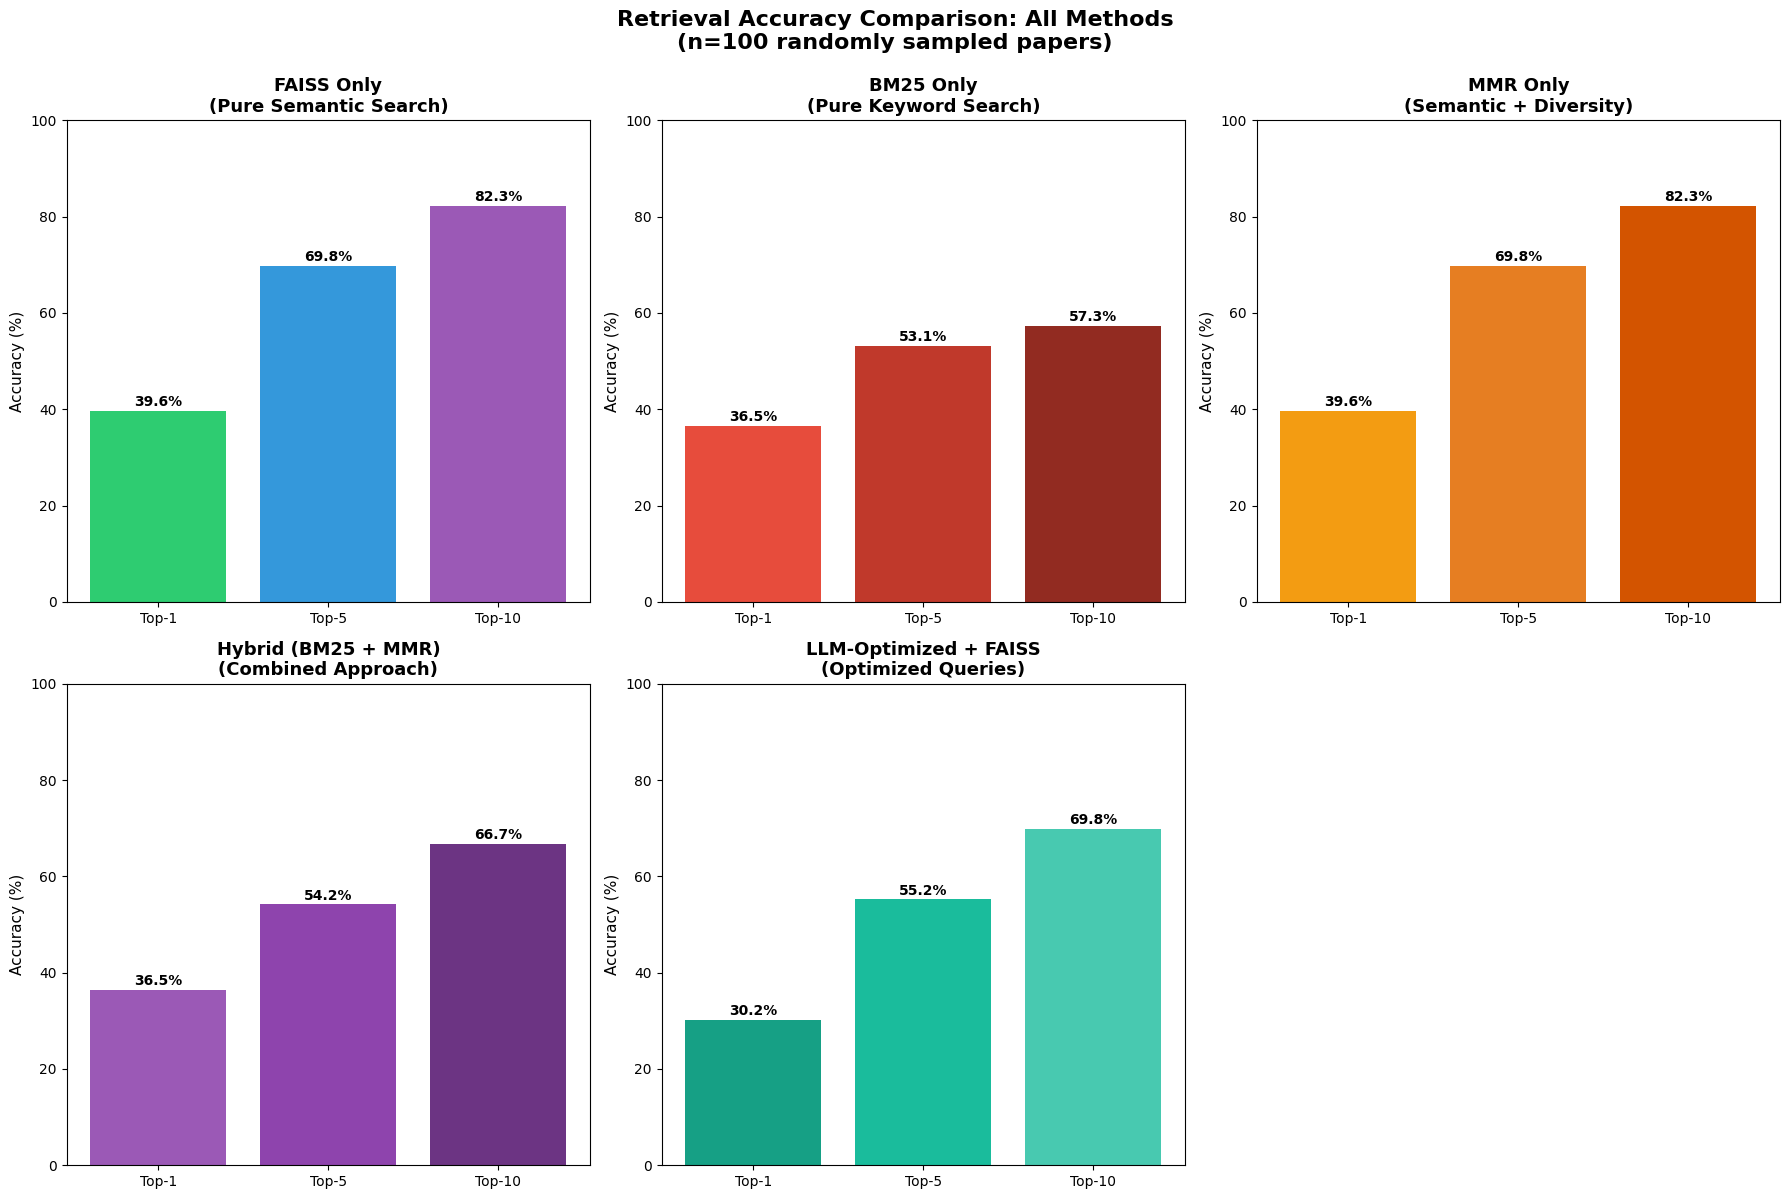


COMPREHENSIVE COMPARISON SUMMARY
Method                                Top-1        Top-5       Top-10
--------------------------------------------------------------------------------------------------------------
FAISS Only                           39.58%       69.79%       82.29%
BM25 Only                            36.46%       53.12%       57.29%
MMR Only                             39.58%       69.79%       82.29%
Hybrid (BM25 + MMR)                  36.46%       54.17%       66.67%
LLM-Optimized + FAISS                30.21%       55.21%       69.79%


In [50]:
# Comprehensive comparison of all five methods
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

metrics = ['Top-1', 'Top-5', 'Top-10']
colors = ['#2ecc71', '#3498db', '#9b59b6']

# Method 1: FAISS Only
faiss_values = [accuracy_results['top_1'], accuracy_results['top_5'], accuracy_results['top_10']]
axes[0, 0].bar(metrics, faiss_values, color=colors)
axes[0, 0].set_title('FAISS Only\n(Pure Semantic Search)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 0].set_ylim(0, 100)
for i, v in enumerate(faiss_values):
    axes[0, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Method 2: BM25 Only
bm25_values = [bm25_accuracy_results['top_1'], bm25_accuracy_results['top_5'], bm25_accuracy_results['top_10']]
axes[0, 1].bar(metrics, bm25_values, color=['#e74c3c', '#c0392b', '#922b21'])
axes[0, 1].set_title('BM25 Only\n(Pure Keyword Search)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 1].set_ylim(0, 100)
for i, v in enumerate(bm25_values):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Method 3: MMR Only
mmr_values = [mmr_accuracy_results['top_1'], mmr_accuracy_results['top_5'], mmr_accuracy_results['top_10']]
axes[0, 2].bar(metrics, mmr_values, color=['#f39c12', '#e67e22', '#d35400'])
axes[0, 2].set_title('MMR Only\n(Semantic + Diversity)', fontsize=13, fontweight='bold')
axes[0, 2].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 2].set_ylim(0, 100)
for i, v in enumerate(mmr_values):
    axes[0, 2].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Method 4: Hybrid (BM25 + MMR)
hybrid_values = [hybrid_accuracy_results['top_1'], hybrid_accuracy_results['top_5'], hybrid_accuracy_results['top_10']]
axes[1, 0].bar(metrics, hybrid_values, color=['#9b59b6', '#8e44ad', '#6c3483'])
axes[1, 0].set_title('Hybrid (BM25 + MMR)\n(Combined Approach)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=11)
axes[1, 0].set_ylim(0, 100)
for i, v in enumerate(hybrid_values):
    axes[1, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Method 5: LLM-Optimized + FAISS
llm_opt_values = [llm_optimized_accuracy_results['top_1'], llm_optimized_accuracy_results['top_5'], llm_optimized_accuracy_results['top_10']]
axes[1, 1].bar(metrics, llm_opt_values, color=['#16a085', '#1abc9c', '#48c9b0'])
axes[1, 1].set_title('LLM-Optimized + FAISS\n(Optimized Queries)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1, 1].set_ylim(0, 100)
for i, v in enumerate(llm_opt_values):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Hide the empty subplot
axes[1, 2].axis('off')

plt.suptitle(f'Retrieval Accuracy Comparison: All Methods\n(n={len(enriched_records)} randomly sampled papers)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*110)
print("COMPREHENSIVE COMPARISON SUMMARY")
print("="*110)
print(f"{'Method':<30} {'Top-1':>12} {'Top-5':>12} {'Top-10':>12}")
print("-"*110)
print(f"{'FAISS Only':<30} {faiss_values[0]:>11.2f}% {faiss_values[1]:>11.2f}% {faiss_values[2]:>11.2f}%")
print(f"{'BM25 Only':<30} {bm25_values[0]:>11.2f}% {bm25_values[1]:>11.2f}% {bm25_values[2]:>11.2f}%")
print(f"{'MMR Only':<30} {mmr_values[0]:>11.2f}% {mmr_values[1]:>11.2f}% {mmr_values[2]:>11.2f}%")
print(f"{'Hybrid (BM25 + MMR)':<30} {hybrid_values[0]:>11.2f}% {hybrid_values[1]:>11.2f}% {hybrid_values[2]:>11.2f}%")
print(f"{'LLM-Optimized + FAISS':<30} {llm_opt_values[0]:>11.2f}% {llm_opt_values[1]:>11.2f}% {llm_opt_values[2]:>11.2f}%")
print("="*110)

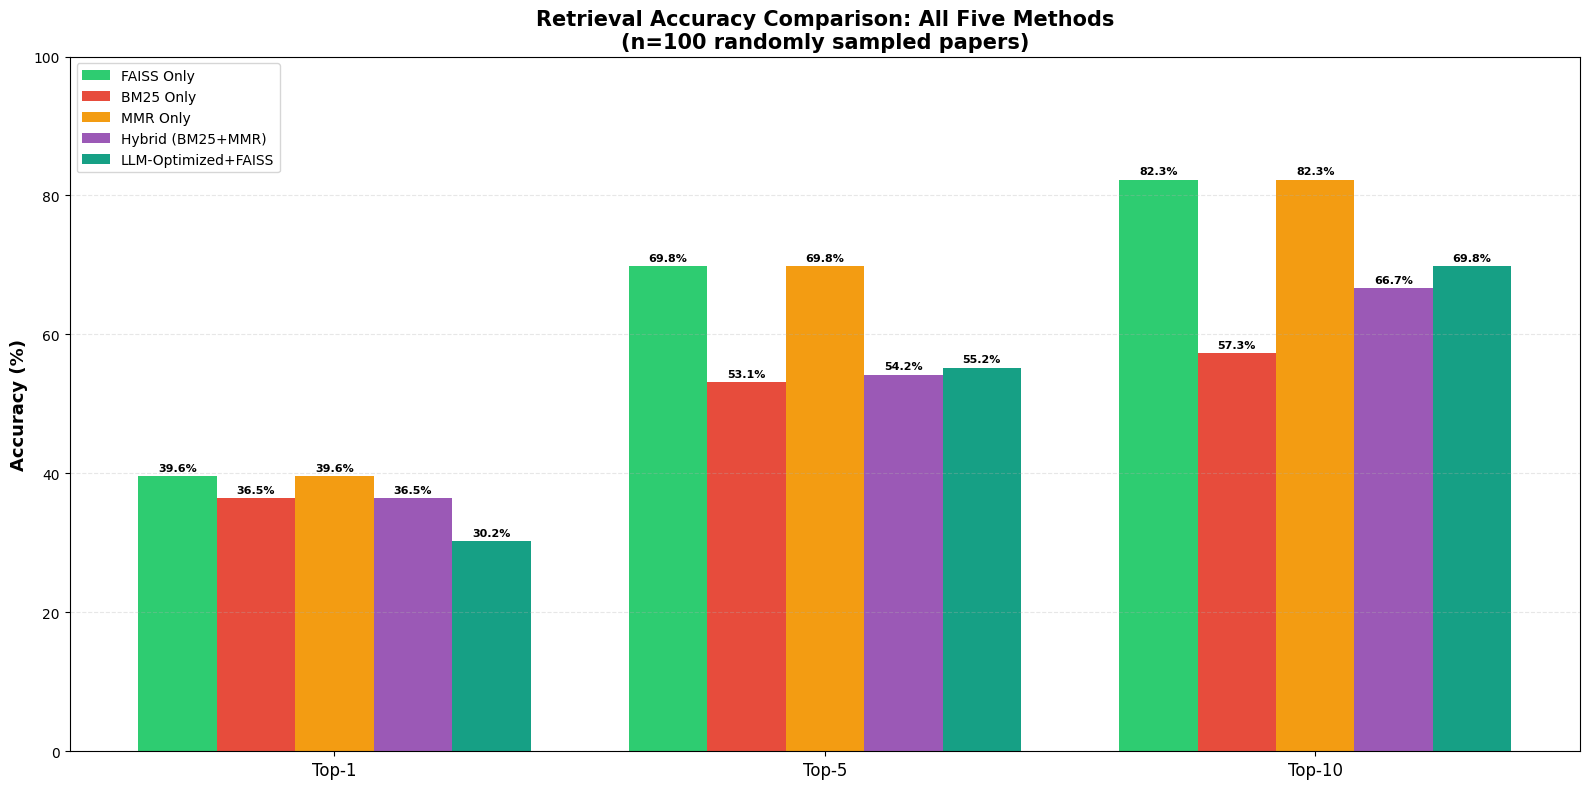

In [51]:
# Grouped bar chart comparing all methods side-by-side
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(16, 8))

metrics = ['Top-1', 'Top-5', 'Top-10']
x = np.arange(len(metrics))
width = 0.16  # Width of each bar (5 methods)

faiss_values = [accuracy_results['top_1'], accuracy_results['top_5'], accuracy_results['top_10']]
bm25_values = [bm25_accuracy_results['top_1'], bm25_accuracy_results['top_5'], bm25_accuracy_results['top_10']]
mmr_values = [mmr_accuracy_results['top_1'], mmr_accuracy_results['top_5'], mmr_accuracy_results['top_10']]
hybrid_values = [hybrid_accuracy_results['top_1'], hybrid_accuracy_results['top_5'], hybrid_accuracy_results['top_10']]
llm_opt_values = [llm_optimized_accuracy_results['top_1'], llm_optimized_accuracy_results['top_5'], llm_optimized_accuracy_results['top_10']]

bars1 = ax.bar(x - 2*width, faiss_values, width, label='FAISS Only', color='#2ecc71')
bars2 = ax.bar(x - width, bm25_values, width, label='BM25 Only', color='#e74c3c')
bars3 = ax.bar(x, mmr_values, width, label='MMR Only', color='#f39c12')
bars4 = ax.bar(x + width, hybrid_values, width, label='Hybrid (BM25+MMR)', color='#9b59b6')
bars5 = ax.bar(x + 2*width, llm_opt_values, width, label='LLM-Optimized+FAISS', color='#16a085')

ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title(f'Retrieval Accuracy Comparison: All Five Methods\n(n={len(enriched_records)} randomly sampled papers)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

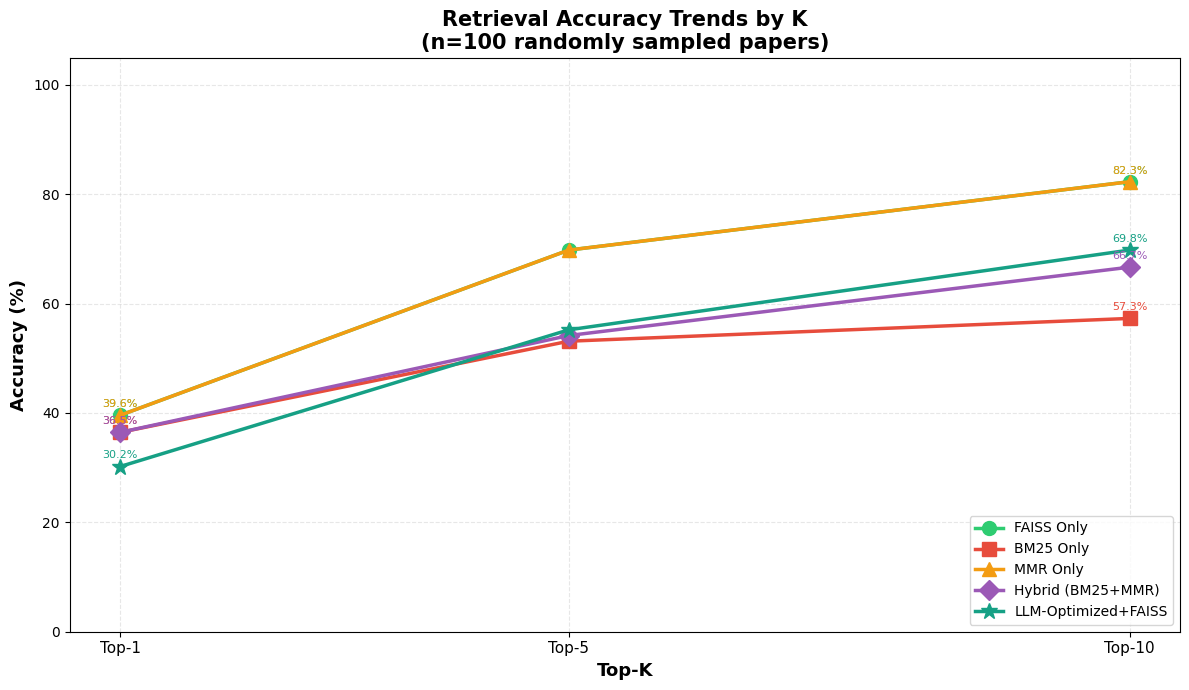

In [52]:
# Line plot showing accuracy trends across Top-1, Top-5, Top-10
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))

metrics_numeric = [1, 5, 10]
faiss_values = [accuracy_results['top_1'], accuracy_results['top_5'], accuracy_results['top_10']]
bm25_values = [bm25_accuracy_results['top_1'], bm25_accuracy_results['top_5'], bm25_accuracy_results['top_10']]
mmr_values = [mmr_accuracy_results['top_1'], mmr_accuracy_results['top_5'], mmr_accuracy_results['top_10']]
hybrid_values = [hybrid_accuracy_results['top_1'], hybrid_accuracy_results['top_5'], hybrid_accuracy_results['top_10']]
llm_opt_values = [llm_optimized_accuracy_results['top_1'], llm_optimized_accuracy_results['top_5'], llm_optimized_accuracy_results['top_10']]

ax.plot(metrics_numeric, faiss_values, marker='o', linewidth=2.5, markersize=10, 
        label='FAISS Only', color='#2ecc71')
ax.plot(metrics_numeric, bm25_values, marker='s', linewidth=2.5, markersize=10, 
        label='BM25 Only', color='#e74c3c')
ax.plot(metrics_numeric, mmr_values, marker='^', linewidth=2.5, markersize=10, 
        label='MMR Only', color='#f39c12')
ax.plot(metrics_numeric, hybrid_values, marker='D', linewidth=2.5, markersize=10, 
        label='Hybrid (BM25+MMR)', color='#9b59b6')
ax.plot(metrics_numeric, llm_opt_values, marker='*', linewidth=2.5, markersize=12, 
        label='LLM-Optimized+FAISS', color='#16a085')

ax.set_xlabel('Top-K', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title(f'Retrieval Accuracy Trends by K\n(n={len(enriched_records)} randomly sampled papers)', 
             fontsize=15, fontweight='bold')
ax.set_xticks([1, 5, 10])
ax.set_xticklabels(['Top-1', 'Top-5', 'Top-10'], fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, linestyle='--')

# Add value labels (only for top-1 and top-10 to avoid clutter)
for i, k in enumerate([1, 10]):
    idx = [1, 5, 10].index(k)
    ax.text(k, faiss_values[idx] + 1.5, f'{faiss_values[idx]:.1f}%', ha='center', fontsize=8, color='#2ecc71')
    ax.text(k, bm25_values[idx] + 1.5, f'{bm25_values[idx]:.1f}%', ha='center', fontsize=8, color='#e74c3c')
    ax.text(k, mmr_values[idx] + 1.5, f'{mmr_values[idx]:.1f}%', ha='center', fontsize=8, color='#f39c12')
    ax.text(k, hybrid_values[idx] + 1.5, f'{hybrid_values[idx]:.1f}%', ha='center', fontsize=8, color='#9b59b6')
    ax.text(k, llm_opt_values[idx] + 1.5, f'{llm_opt_values[idx]:.1f}%', ha='center', fontsize=8, color='#16a085')

plt.tight_layout()
plt.show()

In [53]:
# Save comprehensive comparison results to JSON
all_methods_comparison = {
    "test_dataset_size": len(enriched_records),
    "methods": {
        "faiss_only": {
            "description": "Pure semantic similarity search",
            "top_1": accuracy_results['top_1'],
            "top_5": accuracy_results['top_5'],
            "top_10": accuracy_results['top_10']
        },
        "bm25_only": {
            "description": "Pure keyword-based search",
            "top_1": bm25_accuracy_results['top_1'],
            "top_5": bm25_accuracy_results['top_5'],
            "top_10": bm25_accuracy_results['top_10']
        },
        "mmr_only": {
            "description": "Semantic search with diversity",
            "top_1": mmr_accuracy_results['top_1'],
            "top_5": mmr_accuracy_results['top_5'],
            "top_10": mmr_accuracy_results['top_10']
        },
        "hybrid_bm25_mmr": {
            "description": "Combined BM25 + MMR approach",
            "top_1": hybrid_accuracy_results['top_1'],
            "top_5": hybrid_accuracy_results['top_5'],
            "top_10": hybrid_accuracy_results['top_10']
        },
        "llm_optimized_faiss": {
            "description": "FAISS with LLM-optimized queries",
            "top_1": llm_optimized_accuracy_results['top_1'],
            "top_5": llm_optimized_accuracy_results['top_5'],
            "top_10": llm_optimized_accuracy_results['top_10']
        }
    },
    "best_performing": {
        "top_1": max([
            ("FAISS", accuracy_results['top_1']),
            ("BM25", bm25_accuracy_results['top_1']),
            ("MMR", mmr_accuracy_results['top_1']),
            ("Hybrid", hybrid_accuracy_results['top_1']),
            ("LLM-Optimized", llm_optimized_accuracy_results['top_1'])
        ], key=lambda x: x[1]),
        "top_5": max([
            ("FAISS", accuracy_results['top_5']),
            ("BM25", bm25_accuracy_results['top_5']),
            ("MMR", mmr_accuracy_results['top_5']),
            ("Hybrid", hybrid_accuracy_results['top_5']),
            ("LLM-Optimized", llm_optimized_accuracy_results['top_5'])
        ], key=lambda x: x[1]),
        "top_10": max([
            ("FAISS", accuracy_results['top_10']),
            ("BM25", bm25_accuracy_results['top_10']),
            ("MMR", mmr_accuracy_results['top_10']),
            ("Hybrid", hybrid_accuracy_results['top_10']),
            ("LLM-Optimized", llm_optimized_accuracy_results['top_10'])
        ], key=lambda x: x[1])
    }
}

all_methods_output_path = Path('all_methods_comparison_results.json')
with all_methods_output_path.open('w') as f:
    json.dump(all_methods_comparison, f, indent=2)

print(f"\nSaved comprehensive comparison results to {all_methods_output_path}")

# Print best performing methods
print("\n" + "="*80)
print("BEST PERFORMING METHODS")
print("="*80)
for metric, (method, score) in all_methods_comparison['best_performing'].items():
    print(f"{metric.upper():>8}: {method:<20} with {score:.2f}% accuracy")
print("="*80)


Saved comprehensive comparison results to all_methods_comparison_results.json

BEST PERFORMING METHODS
   TOP_1: FAISS                with 39.58% accuracy
   TOP_5: FAISS                with 69.79% accuracy
  TOP_10: FAISS                with 82.29% accuracy


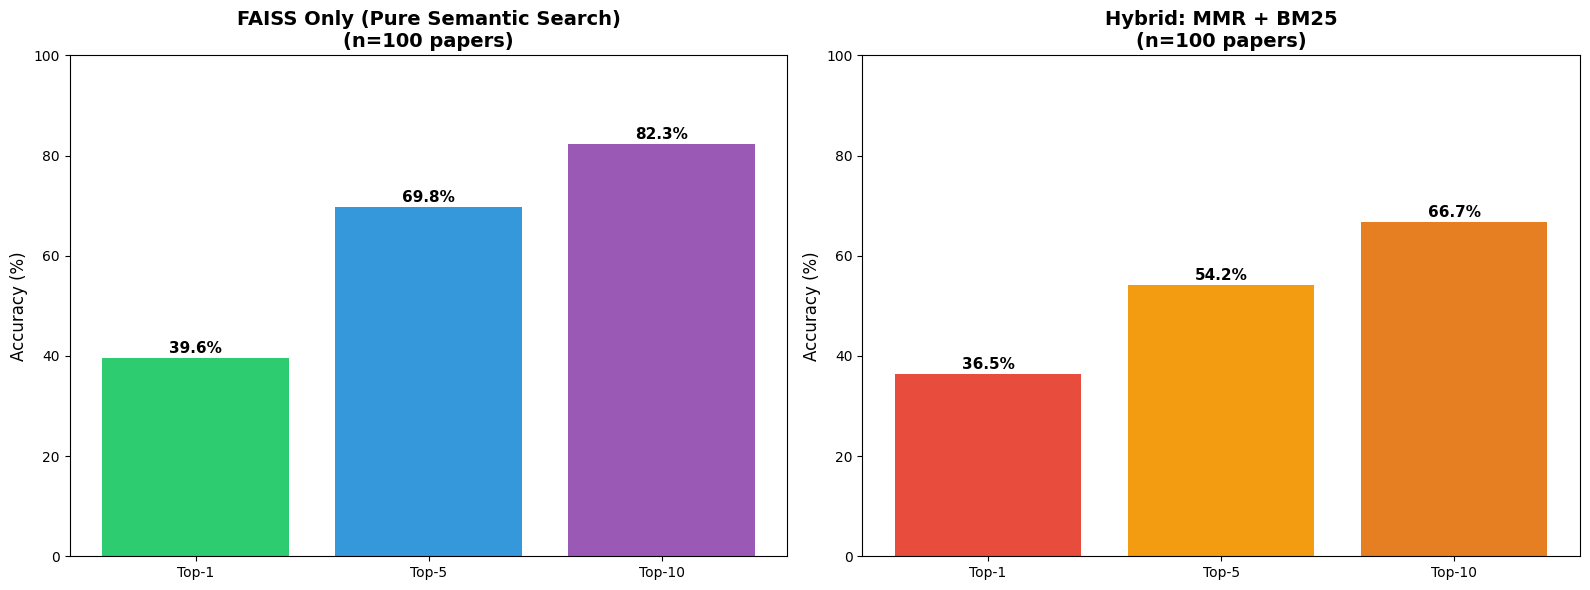


COMPARISON SUMMARY: FAISS vs Hybrid
Top-1: FAISS=39.58% | Hybrid=36.46% | Difference=-3.12%
Top-5: FAISS=69.79% | Hybrid=54.17% | Difference=-15.62%
Top-10: FAISS=82.29% | Hybrid=66.67% | Difference=-15.62%


In [54]:
# Comparison visualization: FAISS only vs Hybrid (MMR + BM25)
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: FAISS only (original)
metrics = ['Top-1', 'Top-5', 'Top-10']
faiss_values = [accuracy_results['top_1'], accuracy_results['top_5'], accuracy_results['top_10']]

ax1.bar(metrics, faiss_values, color=['#2ecc71', '#3498db', '#9b59b6'])
ax1.set_title(f'FAISS Only (Pure Semantic Search)\n(n={len(enriched_records)} papers)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_ylim(0, 100)

for i, v in enumerate(faiss_values):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Plot 2: Hybrid (MMR + BM25)
hybrid_values = [hybrid_accuracy_results['top_1'], hybrid_accuracy_results['top_5'], hybrid_accuracy_results['top_10']]

ax2.bar(metrics, hybrid_values, color=['#e74c3c', '#f39c12', '#e67e22'])
ax2.set_title(f'Hybrid: MMR + BM25\n(n={len(enriched_records)} papers)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_ylim(0, 100)

for i, v in enumerate(hybrid_values):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print improvement summary
print("\n" + "="*80)
print("COMPARISON SUMMARY: FAISS vs Hybrid")
print("="*80)
for i, metric in enumerate(['Top-1', 'Top-5', 'Top-10']):
    improvement = hybrid_values[i] - faiss_values[i]
    print(f"{metric}: FAISS={faiss_values[i]:.2f}% | Hybrid={hybrid_values[i]:.2f}% | Difference={improvement:+.2f}%")
print("="*80)

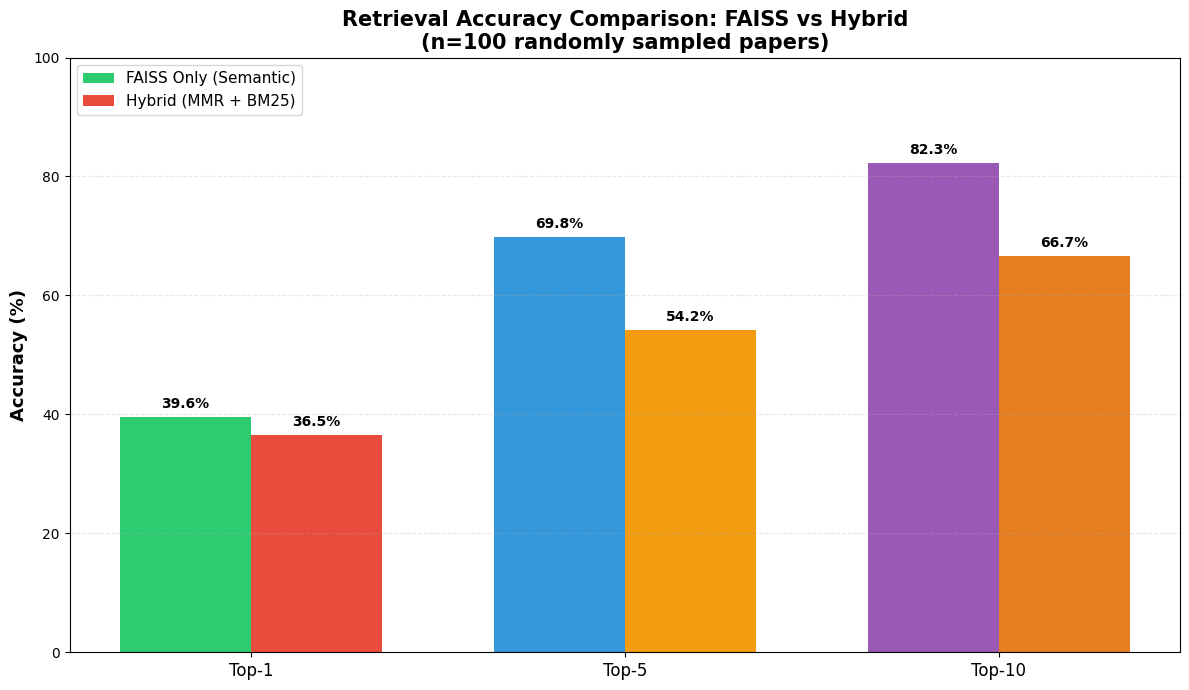

In [55]:
# Side-by-side comparison with grouped bars
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))

metrics = ['Top-1', 'Top-5', 'Top-10']
x = np.arange(len(metrics))
width = 0.35

faiss_values = [accuracy_results['top_1'], accuracy_results['top_5'], accuracy_results['top_10']]
hybrid_values = [hybrid_accuracy_results['top_1'], hybrid_accuracy_results['top_5'], hybrid_accuracy_results['top_10']]

bars1 = ax.bar(x - width/2, faiss_values, width, label='FAISS Only (Semantic)', 
               color=['#2ecc71', '#3498db', '#9b59b6'])
bars2 = ax.bar(x + width/2, hybrid_values, width, label='Hybrid (MMR + BM25)', 
               color=['#e74c3c', '#f39c12', '#e67e22'])

ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title(f'Retrieval Accuracy Comparison: FAISS vs Hybrid\n(n={len(enriched_records)} randomly sampled papers)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Optional: Save comparison results to JSON for later analysis
comparison_results = {
    "test_dataset_size": len(enriched_records),
    "faiss_only": {
        "top_1": accuracy_results['top_1'],
        "top_5": accuracy_results['top_5'],
        "top_10": accuracy_results['top_10']
    },
    "hybrid_mmr_bm25": {
        "top_1": hybrid_accuracy_results['top_1'],
        "top_5": hybrid_accuracy_results['top_5'],
        "top_10": hybrid_accuracy_results['top_10']
    },
    "improvements": {
        "top_1": hybrid_accuracy_results['top_1'] - accuracy_results['top_1'],
        "top_5": hybrid_accuracy_results['top_5'] - accuracy_results['top_5'],
        "top_10": hybrid_accuracy_results['top_10'] - accuracy_results['top_10']
    }
}

comparison_output_path = Path('retrieval_comparison_results.json')
with comparison_output_path.open('w') as f:
    json.dump(comparison_results, f, indent=2)

print(f"Saved comparison results to {comparison_output_path}")
print("\nComparison Summary:")
print(json.dumps(comparison_results, indent=2))

Saved comparison results to retrieval_comparison_results.json

Comparison Summary:
{
  "test_dataset_size": 100,
  "faiss_only": {
    "top_1": 39.58333333333333,
    "top_5": 69.79166666666666,
    "top_10": 82.29166666666666
  },
  "hybrid_mmr_bm25": {
    "top_1": 36.45833333333333,
    "top_5": 54.166666666666664,
    "top_10": 66.66666666666666
  },
  "improvements": {
    "top_1": -3.125,
    "top_5": -15.624999999999993,
    "top_10": -15.625
  }
}


: 